In [36]:
#IMPORTAZIONE DELLE LIBRERIE

import numpy as np
import random as rd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os


In [37]:
percorso=r"C:\Users\vince\Desktop\esperienza_laboratorio_DOP\set_tel_mio"

In [77]:
immagine=Image.open(percorso+r"\4.1.jpeg")


In [78]:
matrice_a_colori=np.array(immagine)
matrice_bn=np.array(immagine.convert('L'))

In [79]:
coords = np.unravel_index(np.argmax(matrice_bn), matrice_bn.shape)
coords

(np.int64(658), np.int64(643))

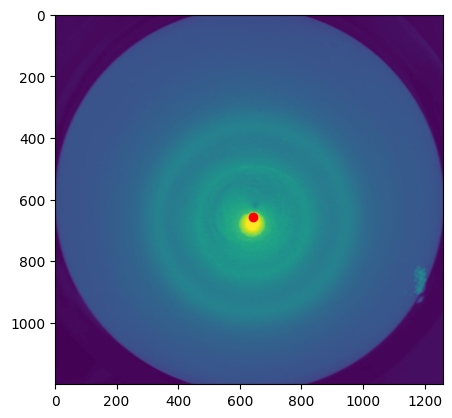

In [83]:
plt.scatter(coords[1], coords[0], c='r')
plt.imshow(matrice_bn)
plt.show()

In [90]:
max=float(matrice_bn.shape[1])

ValueError: x and y must have same first dimension, but have shapes (50,) and (1259,)

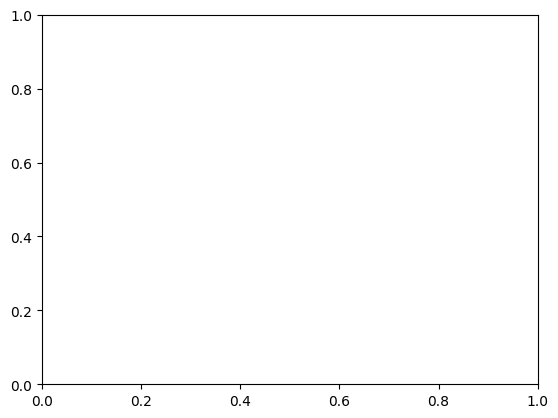

In [91]:
x=(np.linspace(0, max)/max)*0.1
y=matrice_bn[coords[1],:]

plt.plot(x,y)

In [ ]:
from scipy.signal import find_peaks, savgol_filter

# Assumendo x e y come array NumPy esistenti
# Filtraggio nell'intervallo [200, 1000]
mask = (x >= 0.01) & (x <= 0.09)
x_f = x[mask]
y_f = y[mask]

# Applicazione del filtro di Savitzky-Golay per ridurre il rumore
# window_length deve essere dispari; polyorder è l'ordine del polinomio
y_smooth = savgol_filter(y_f, window_length=0.01, polyorder=1)

# Identificazione dei picchi sul segnale filtrato
# Si consiglia di calibrare 'prominence' in base alla deviazione standard del rumore
indices, properties = find_peaks(y_smooth, prominence=51, width=10)

x_massimi = x_f[indices]
y_massimi = y_f[indices] # o y_smooth[indices] per il valore filtrato

print(f"Massimi individuati: {len(x_massimi)}")
print(f"Coordinate x: {x_massimi}")

ValueError: polyorder must be less than window_length.